<a href="https://colab.research.google.com/github/layaltalali9/layallap/blob/main/lap5LAYAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gaussian noisy: 0.005970281263164148
Mean: 0.0018401174688395942
Geometric: 0.0030261817620081772
Impulse noisy: 0.026691299
Median: 0.001065894


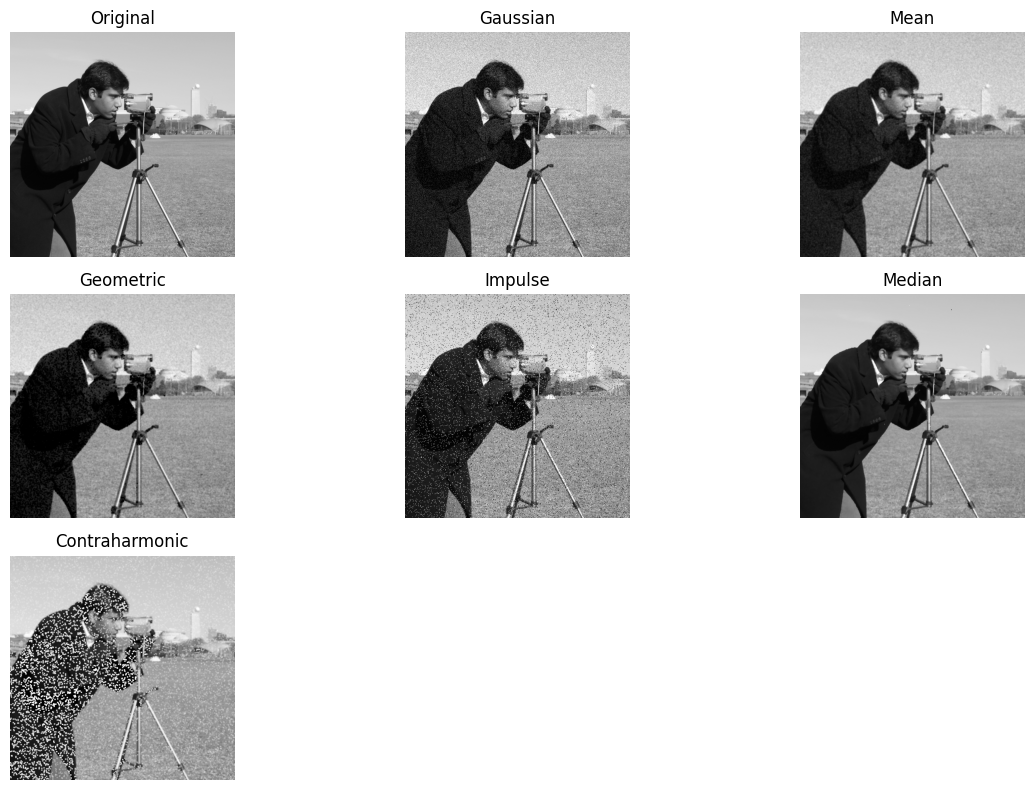

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util
from scipy.ndimage import uniform_filter, median_filter

# load image
img = data.camera().astype(np.float32) / 255.0

# MSE function
def mse(a, b):
    return np.mean((a - b)**2)


# Gaussian noise

rng = np.random.default_rng(0)
noise = rng.normal(0, 0.08, img.shape)
g = np.clip(img + noise, 0, 1)

# filters
mean3 = uniform_filter(g, size=3)

def geometric_mean(im, size=3):
    eps = 1e-6
    log = np.log(im + eps)
    return np.exp(uniform_filter(log, size=size))

geo3 = geometric_mean(g)


# Salt & pepper noise

sp = util.random_noise(img, mode="s&p", amount=0.08)

med3 = median_filter(sp, size=3)

# contraharmonic
from scipy.ndimage import generic_filter
def contra(im, Q):
    def f(w):
        w = np.array(w)
        return np.sum(w**(Q+1)) / (np.sum(w**Q) + 1e-6)
    return generic_filter(im, f, size=3)

contra_res = contra(sp, Q=1.5)


# MSE results

print("Gaussian noisy:", mse(img, g))
print("Mean:", mse(img, mean3))
print("Geometric:", mse(img, geo3))

print("Impulse noisy:", mse(img, sp))
print("Median:", mse(img, med3))


# display

titles = ["Original","Gaussian","Mean","Geometric",
          "Impulse","Median","Contraharmonic"]
images = [img,g,mean3,geo3,sp,med3,contra_res]

plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

## **Discussion**

In this project we tested two types of noise which are Gaussian noise and salt and pepper noise.

For Gaussian noise the image became slightly noisy but still smooth. When we applied the mean filter it reduced the noise but made the image more blurry especially with larger window size. The geometric mean filter gave better result because it reduced noise while keeping edges more clear.

For salt and pepper noise the image had black and white pixels randomly. The median filter worked very well because it removed these pixels without affecting the rest of the image too much. The contraharmonic filter also worked but it depends on the value of Q. If Q is not chosen correctly the result becomes worse.

From the MSE values we can see that filters reduce the error compared to the noisy image. However sometimes the visual quality is more important because some filters remove noise but also remove important details.

Overall the choice of filter depends on the type of noise. Gaussian noise works better with mean based filters while salt and pepper noise works better with median based filters.

## **Reflection Questions**

1

Restoration is more objective because it tries to recover the original image using a known model. Enhancement depends on visual preference so it is subjective.

2

We must identify the noise type first because each noise requires a different filter. Using the wrong filter will not remove noise properly and may damage the image.

3

There is no single best filter because different filters work for different noise types. Also there is always a trade off between removing noise and keeping image details.